Import Analyte objects

In [15]:
from matplotlib import pyplot as plt
from MASSIVE.analytes import Analyte, Oligo, Peptide

Define analytes


In [16]:
# Analytes can be defined by their elemental composition
demo_analyte = Analyte(name='ATP', composition={'C': 10, 'H': 16, 'N': 5, 'O': 13, 'P': 3})

# for oligos, you can define them by their nucleotide sequence
demo_oligo = Oligo(name='Demo Oligo', seq='GAAAGACCACA')

# for peptides, you can define them by their amino acid sequence
demo_peptide = Peptide(name='Demo Peptide', seq='METKVADETNSRA')

In [17]:
# useful attributes are automatically calculated:
demo_oligo.composition

{'H': 133, 'N': 49, 'P': 10, 'O': 58, 'C': 107}

In [18]:
demo_oligo.monoisotopic_mass

3342.641

In [19]:
demo_oligo.average_mass

3344.244

In [20]:
demo_oligo.isotopic_distribution

[Peak(mz=3342.641296, intensity=0.226239, charge=1),
 Peak(mz=3343.643874, intensity=0.310782, charge=1),
 Peak(mz=3344.646343, intensity=0.238932, charge=1),
 Peak(mz=3345.648761, intensity=0.132735, charge=1),
 Peak(mz=3346.651145, intensity=0.059008, charge=1),
 Peak(mz=3347.653503, intensity=0.022160, charge=1),
 Peak(mz=3348.655841, intensity=0.007269, charge=1),
 Peak(mz=3349.658164, intensity=0.002130, charge=1),
 Peak(mz=3350.660475, intensity=0.000567, charge=1),
 Peak(mz=3351.662774, intensity=0.000139, charge=1),
 Peak(mz=3352.665065, intensity=0.000031, charge=1),
 Peak(mz=3353.667347, intensity=0.000007, charge=1),
 Peak(mz=3354.669623, intensity=0.000001, charge=1),
 Peak(mz=3355.671892, intensity=0.000000, charge=1),
 Peak(mz=3356.674155, intensity=0.000000, charge=1),
 Peak(mz=3357.676414, intensity=0.000000, charge=1),
 Peak(mz=3358.678668, intensity=0.000000, charge=1),
 Peak(mz=3359.680918, intensity=0.000000, charge=1)]

In [21]:
# you can browse the available modifications for each class, which are defined as atomic changes relative to unmodified analyte
Oligo.KNOWN_MODIFICATIONS

{'methyl': {'C': 1, 'H': 2, 'N': 0, 'O': 0, 'P': 0, 'S': 0},
 'hydroxymethyl': {'C': 1, 'H': 3, 'N': 0, 'O': 1, 'P': 0, 'S': 0},
 'formyl': {'C': 1, 'H': 1, 'N': 0, 'O': 1, 'P': 0, 'S': 0},
 'carboxy': {'C': 1, 'H': 0, 'N': 0, 'O': 2, 'P': 0, 'S': 0},
 'PS': {'C': 0, 'H': 0, 'N': 0, 'O': -1, 'P': 0, 'S': 1},
 'adenylation': {'C': 10, 'H': 14, 'N': 5, 'O': 5, 'P': 1, 'S': 0},
 '3P': {'C': 0, 'H': 1, 'N': 0, 'O': 3, 'P': 1, 'S': 0},
 '5P': {'C': 0, 'H': 1, 'N': 0, 'O': 3, 'P': 1, 'S': 0},
 '5PP': {'C': 0, 'H': 2, 'N': 0, 'O': 6, 'P': 2, 'S': 0},
 '5PPP': {'C': 0, 'H': 3, 'N': 0, 'O': 9, 'P': 3, 'S': 0},
 '5AmMC12': {'C': 12, 'H': 26, 'N': 1, 'O': 3, 'P': 1, 'S': 0}}

In [22]:
# or define your own
my_mod = {'C': 3, 'H': 7, 'O': 1}

In [23]:
# modifications can be added by name or by composition to an Analyte
oligo_5phos =  Oligo(name='5-Phosphorylated Oligo', seq='GAAAGACCACA', mods='5P')
oligo_custom =  Oligo(name='Custom modified Oligo', seq='GAAAGACCACA', mods=my_mod)
oligo_combo =  Oligo(name='Multiple mods Oligo', seq='GAAAGACCACA', mods=['5P', my_mod])

# composition is updated automatically
oligo_5phos.composition

{'H': 134, 'S': 0, 'O': 61, 'C': 107, 'N': 49, 'P': 11}

In [24]:
# Analytes are by default singly charged and positive, but can have any integer charge (positive or negative)
analyte_pos = Analyte(name='ATP', composition={'C': 10, 'H': 16, 'N': 5, 'O': 13, 'P': 3}, charge=1)
analyte_pos = Analyte(name='ATP', composition={'C': 10, 'H': 16, 'N': 5, 'O': 13, 'P': 3}, charge=2)
analyte_neg = Analyte(name='ATP', composition={'C': 10, 'H': 16, 'N': 5, 'O': 13, 'P': 3}, charge=-1)

<Axes: title={'left': 'Demo Peptide'}, xlabel='m/z', ylabel='Intensity (au)'>

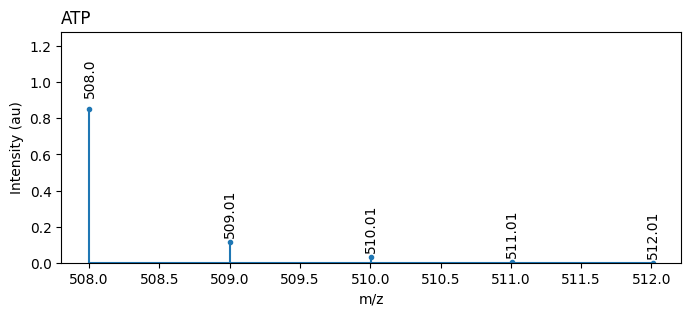

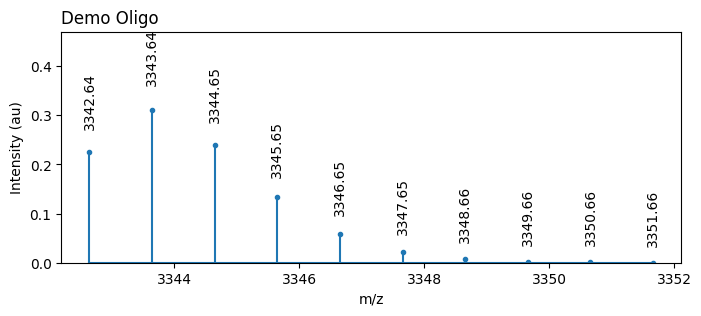

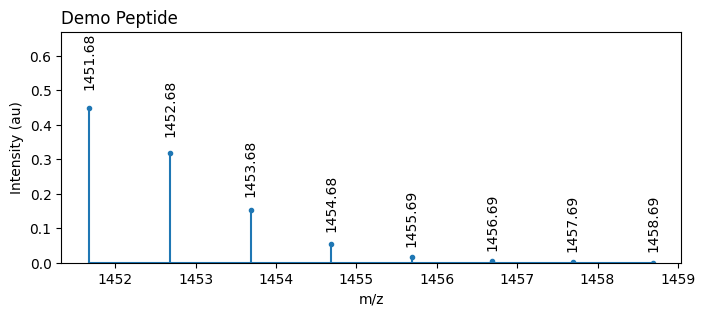

In [25]:
# Analytes can be plotted separately
demo_analyte.plot()
demo_oligo.plot()
demo_peptide.plot()

Text(0, 0.5, 'Relative intensity')

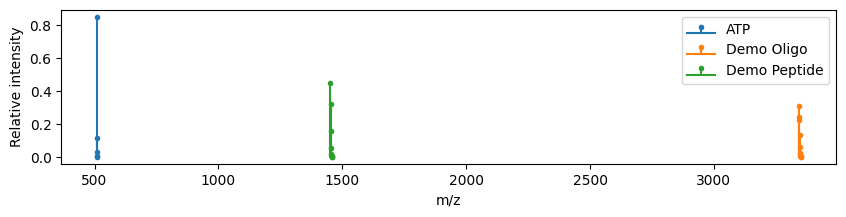

In [26]:
# You can plot multiple analytes on the same axis

fig, ax = plt.subplots(figsize=(10,2))

for i, analyte in enumerate([demo_analyte, demo_oligo, demo_peptide]):
    analyte.plot(ax=ax, # add oligos to existing axis
                 label=analyte.name,    # name each analyte for legend
                 mass_labels=False)    # remove individual mass labels

ax.legend()
ax.set_xlabel('m/z')
ax.set_ylabel('Relative intensity')